<a href="https://colab.research.google.com/github/AniruddhaGhosh64/india_runs/blob/main/INDIA_Runs_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libaries Installation and Code File Initialization

In [ ]:
import os
import gzip
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/candidates.jsonl"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_PATH}\n\n"
        "Check the exact location in Google Drive."
    )

print("✅ Dataset Found")

✅ Dataset Found


# A. Dataset Load & Snapshot

Purpose:    

*   Verify loading worked
*   inspect the first candidate.  


In [ ]:
LIMIT = None

def load_sample(fname, limit=None):
    data = []

    if fname.endswith(".gz"):
        open_func = gzip.open
        mode = "rt"
    else:
        open_func = open
        mode = "r"

    with open_func(fname, mode, encoding="utf-8") as f:
        for i, line in enumerate(f):

            if i >= limit:
                break

            try:
                data.append(json.loads(line))

            except Exception as e:
                print(f"Skipping line {i}: {e}")

    return data


print(f"Loading first {LIMIT} candidates...")

candidates = load_sample(DATA_PATH, LIMIT)

print(f"✅ Successfully loaded {len(candidates)} candidates")

print("\nTop-level keys:")
print(candidates[0].keys())

import pprint

print("\nFirst Candidate:")
pprint.pprint(candidates[0])

Loading first 100000 candidates...
✅ Successfully loaded 100000 candidates

Top-level keys:
dict_keys(['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals'])

First Candidate:
{'candidate_id': 'CAND_0000001',
 'career_history': [{'company': 'Mindtree',
                     'company_size': '10001+',
                     'description': 'Implemented streaming data pipelines on '
                                    'Kafka and Spark Streaming for a real-time '
                                    'user-activity processing platform. '
                                    'Designed the schema-registry integration, '
                                    'the watermark/state management approach, '
                                    'and the deduplication logic for '
                                    'late-arriving events. Worked closely with '
                                    'the data science team to make sure '
                

# B. Initial DataFrame Creation

Purpose:

*   Convert raw JSON objects into a DataFrame
*   understand overall dataset shape.

In [ ]:
df_sample = pd.DataFrame(candidates)

print("Shape:", df_sample.shape)

display(df_sample.head())

print("\nColumns:")
print(df_sample.columns.tolist())

print("\nDataFrame Info:")
df_sample.info()

Shape: (100000, 8)


,candidate_id,profile,career_history,education,skills,certifications,languages,redrob_signals
0,CAND_0000001,"{'anonymized_name': 'Ira Vora', 'headline': 'B...","[{'company': 'Mindtree', 'title': 'Backend Eng...",[{'institution': 'Lovely Professional Universi...,"[{'name': 'Tailwind', 'proficiency': 'intermed...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 86.9, 'signup_d..."
1,CAND_0000002,"{'anonymized_name': 'Saanvi Sethi', 'headline'...","[{'company': 'Wipro', 'title': 'Operations Man...","[{'institution': 'Local Engineering College', ...","[{'name': 'Project Management', 'proficiency':...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 78.7, 'signup_d..."
2,CAND_0000003,"{'anonymized_name': 'Yash Agarwal', 'headline'...","[{'company': 'TCS', 'title': 'Customer Support...","[{'institution': 'Local Engineering College', ...","[{'name': 'Angular', 'proficiency': 'intermedi...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 31.9, 'signup_d..."
3,CAND_0000004,"{'anonymized_name': 'Anil Bose', 'headline': '...","[{'company': 'Dunder Mifflin', 'title': 'Marke...","[{'institution': 'Local Engineering College', ...","[{'name': 'Node.js', 'proficiency': 'intermedi...","[{'name': 'AWS Certified Cloud Practitioner', ...","[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 28.5, 'signup_d..."
4,CAND_0000005,"{'anonymized_name': 'Aisha Sethi', 'headline':...","[{'company': 'Stark Industries', 'title': 'Acc...","[{'institution': 'Chandigarh University', 'deg...","[{'name': 'SQL', 'proficiency': 'beginner', 'e...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 84.6, 'signup_d..."



Columns:
['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals']

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   candidate_id    100000 non-null  object
 1   profile         100000 non-null  object
 2   career_history  100000 non-null  object
 3   education       100000 non-null  object
 4   skills          100000 non-null  object
 5   certifications  100000 non-null  object
 6   languages       100000 non-null  object
 7   redrob_signals  100000 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


# C. Schema Discovery

Purpose: Understand nested structure.

In [ ]:
for col in df_sample.columns:

    print(f"\n{'='*60}")
    print(col)

    sample = df_sample[col].iloc[0]

    print("Type:", type(sample))

    if isinstance(sample, dict):

        print("\nKeys:")
        print(sample.keys())

    elif isinstance(sample, list):

        print("\nLength:", len(sample))

        if len(sample) > 0:
            print("First item type:", type(sample[0]))


candidate_id
Type: <class 'str'>

profile
Type: <class 'dict'>

Keys:
dict_keys(['anonymized_name', 'headline', 'summary', 'location', 'country', 'years_of_experience', 'current_title', 'current_company', 'current_company_size', 'current_industry'])

career_history
Type: <class 'list'>

Length: 2
First item type: <class 'dict'>

education
Type: <class 'list'>

Length: 1
First item type: <class 'dict'>

skills
Type: <class 'list'>

Length: 17
First item type: <class 'dict'>

certifications
Type: <class 'list'>

Length: 0

languages
Type: <class 'list'>

Length: 2
First item type: <class 'dict'>

redrob_signals
Type: <class 'dict'>

Keys:
dict_keys(['profile_completeness_score', 'signup_date', 'last_active_date', 'open_to_work_flag', 'profile_views_received_30d', 'applications_submitted_30d', 'recruiter_response_rate', 'avg_response_time_hours', 'skill_assessment_scores', 'connection_count', 'endorsements_received', 'notice_period_days', 'expected_salary_range_inr_lpa', 'preferred_work_

# D. Dataset Health Check
Purpose: Find


*   Null values
*   Empty lists
*   Empty dictionaries

In [ ]:
print("=" * 60)
print("TOP LEVEL NULL ANALYSIS")
print("=" * 60)

null_summary = df_sample.isna().sum()

display(
    null_summary.sort_values(
        ascending=False
    )
)

print("\n")

print("=" * 60)
print("EMPTY LIST / DICT ANALYSIS")
print("=" * 60)

for col in df_sample.columns:

    first_value = df_sample[col].iloc[0]

    if isinstance(first_value, list):

        empty_count = df_sample[col].apply(
            lambda x: len(x) == 0 if isinstance(x, list) else True
        ).sum()

        print(
            f"{col:<20}"
            f" Empty Lists: {empty_count:,}"
            f" ({empty_count/len(df_sample)*100:.2f}%)"
        )

    elif isinstance(first_value, dict):

        empty_count = df_sample[col].apply(
            lambda x: len(x) == 0 if isinstance(x, dict) else True
        ).sum()

        print(
            f"{col:<20}"
            f" Empty Dicts: {empty_count:,}"
            f" ({empty_count/len(df_sample)*100:.2f}%)"
        )

TOP LEVEL NULL ANALYSIS


,0
candidate_id,0
profile,0
career_history,0
education,0
skills,0
certifications,0
languages,0
redrob_signals,0




EMPTY LIST / DICT ANALYSIS
profile              Empty Dicts: 0 (0.00%)
career_history       Empty Lists: 0 (0.00%)
education            Empty Lists: 0 (0.00%)
skills               Empty Lists: 0 (0.00%)
certifications       Empty Lists: 75,019 (75.02%)
languages            Empty Lists: 0 (0.00%)
redrob_signals       Empty Dicts: 0 (0.00%)


# E. Flatten Core Candidate Signals

Purpose: Create the first usable tabular dataset.

In [ ]:
rows = []

for candidate in candidates:

    profile = candidate.get("profile", {})
    signals = candidate.get("redrob_signals", {})

    rows.append({

        "candidate_id":
            candidate.get("candidate_id"),

        "anonymized_name":
            profile.get("anonymized_name"),

        "headline":
            profile.get("headline"),

        "summary":
            profile.get("summary"),

        "location":
            profile.get("location"),

        "country":
            profile.get("country"),

        "years_of_experience":
            profile.get("years_of_experience"),

        "current_title":
            profile.get("current_title"),

        "current_company":
            profile.get("current_company"),

        "current_company_size":
            profile.get("current_company_size"),

        "current_industry":
            profile.get("current_industry"),

        "profile_completeness_score":
            signals.get("profile_completeness_score"),

        "signup_date":
            signals.get("signup_date"),

        "last_active_date":
            signals.get("last_active_date"),

        "open_to_work_flag":
            signals.get("open_to_work_flag"),

        "profile_views_received_30d":
            signals.get("profile_views_received_30d"),

        "applications_submitted_30d":
            signals.get("applications_submitted_30d"),

        "recruiter_response_rate":
            signals.get("recruiter_response_rate"),

        "avg_response_time_hours":
            signals.get("avg_response_time_hours"),

        "connection_count":
            signals.get("connection_count"),

        "endorsements_received":
            signals.get("endorsements_received"),

        "notice_period_days":
            signals.get("notice_period_days"),

        "preferred_work_mode":
            signals.get("preferred_work_mode"),

        "willing_to_relocate":
            signals.get("willing_to_relocate"),

        "github_activity_score":
            signals.get("github_activity_score"),

        "search_appearance_30d":
            signals.get("search_appearance_30d"),

        "saved_by_recruiters_30d":
            signals.get("saved_by_recruiters_30d"),

        "interview_completion_rate":
            signals.get("interview_completion_rate"),

        "offer_acceptance_rate":
            signals.get("offer_acceptance_rate"),

        "verified_email":
            signals.get("verified_email"),

        "verified_phone":
            signals.get("verified_phone"),

        "linkedin_connected":
            signals.get("linkedin_connected")
    })

flat_df = pd.DataFrame(rows)

print("Shape:", flat_df.shape)

display(flat_df.head())

Shape: (100000, 32)


,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,preferred_work_mode,willing_to_relocate,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate,verified_email,verified_phone,linkedin_connected
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,...,onsite,False,9.2,249,4,0.71,0.58,True,True,False
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,...,flexible,False,-1.0,107,10,0.62,-1.00,False,False,False
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,...,hybrid,False,-1.0,28,4,0.86,-1.00,True,False,False
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,...,onsite,True,-1.0,5,8,0.35,-1.00,True,True,True
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,...,hybrid,True,-1.0,67,1,0.74,-1.00,False,True,True


# F. Missing & Sentinel Value Analysis

Purpose: Detect

*   NaN
*   -1
*   0

hidden missing values.

In [ ]:
audit = {}

for col in flat_df.columns:

    audit[col] = {
        "unique_values": flat_df[col].nunique(),
        "missing_nulls": flat_df[col].isna().sum()
    }

    if flat_df[col].dtype in ["int64", "float64"]:

        audit[col]["negative_ones"] = (
            flat_df[col] == -1
        ).sum()

        audit[col]["zeros"] = (
            flat_df[col] == 0
        ).sum()

summary_df = pd.DataFrame(audit).T

display(summary_df)

,unique_values,missing_nulls,negative_ones,zeros
candidate_id,100000.0,0.0,NaN,NaN
anonymized_name,3312.0,0.0,NaN,NaN
headline,2469.0,0.0,NaN,NaN
summary,3241.0,0.0,NaN,NaN
location,28.0,0.0,NaN,NaN
country,8.0,0.0,NaN,NaN
years_of_experience,148.0,0.0,0.0,0.0
current_title,47.0,0.0,NaN,NaN
current_company,63.0,0.0,NaN,NaN
current_company_size,7.0,0.0,NaN,NaN


In [ ]:
for col in flat_df.columns:

    if flat_df[col].dtype in ["int64", "float64"]:

        neg_one_count = (
            flat_df[col] == -1
        ).sum()

        if neg_one_count > 0:

            print(
                f"{col:<35}"
                f"{neg_one_count} rows "
                f"({neg_one_count/len(flat_df)*100:.2f}%)"
            )

github_activity_score              64637 rows (64.64%)
offer_acceptance_rate              59554 rows (59.55%)


# G. Candidate Completeness Analysis

Purpose: Measure profile richness.

Questions:
*   How many skills per candidate?
*   How many career entries?
*   How many education records?
*   How many certifications?
*   How many languages?

In [ ]:
counts_df = pd.DataFrame({
    "num_skills":
        df_sample["skills"].apply(len),

    "num_career_entries":
        df_sample["career_history"].apply(len),

    "num_education":
        df_sample["education"].apply(len),

    "num_certifications":
        df_sample["certifications"].apply(len),

    "num_languages":
        df_sample["languages"].apply(len)
})

display(counts_df.describe())

,num_skills,num_career_entries,num_education,num_certifications,num_languages
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.0
mean,9.60302,3.001710,1.397780,0.374840,2.0
std,3.31163,1.522442,0.489442,0.696046,0.0
min,5.00000,1.000000,1.000000,0.000000,2.0
25%,7.00000,2.000000,1.000000,0.000000,2.0
50%,9.00000,3.000000,1.000000,0.000000,2.0
75%,11.00000,4.000000,2.000000,0.000000,2.0
max,23.00000,9.000000,2.000000,3.000000,2.0


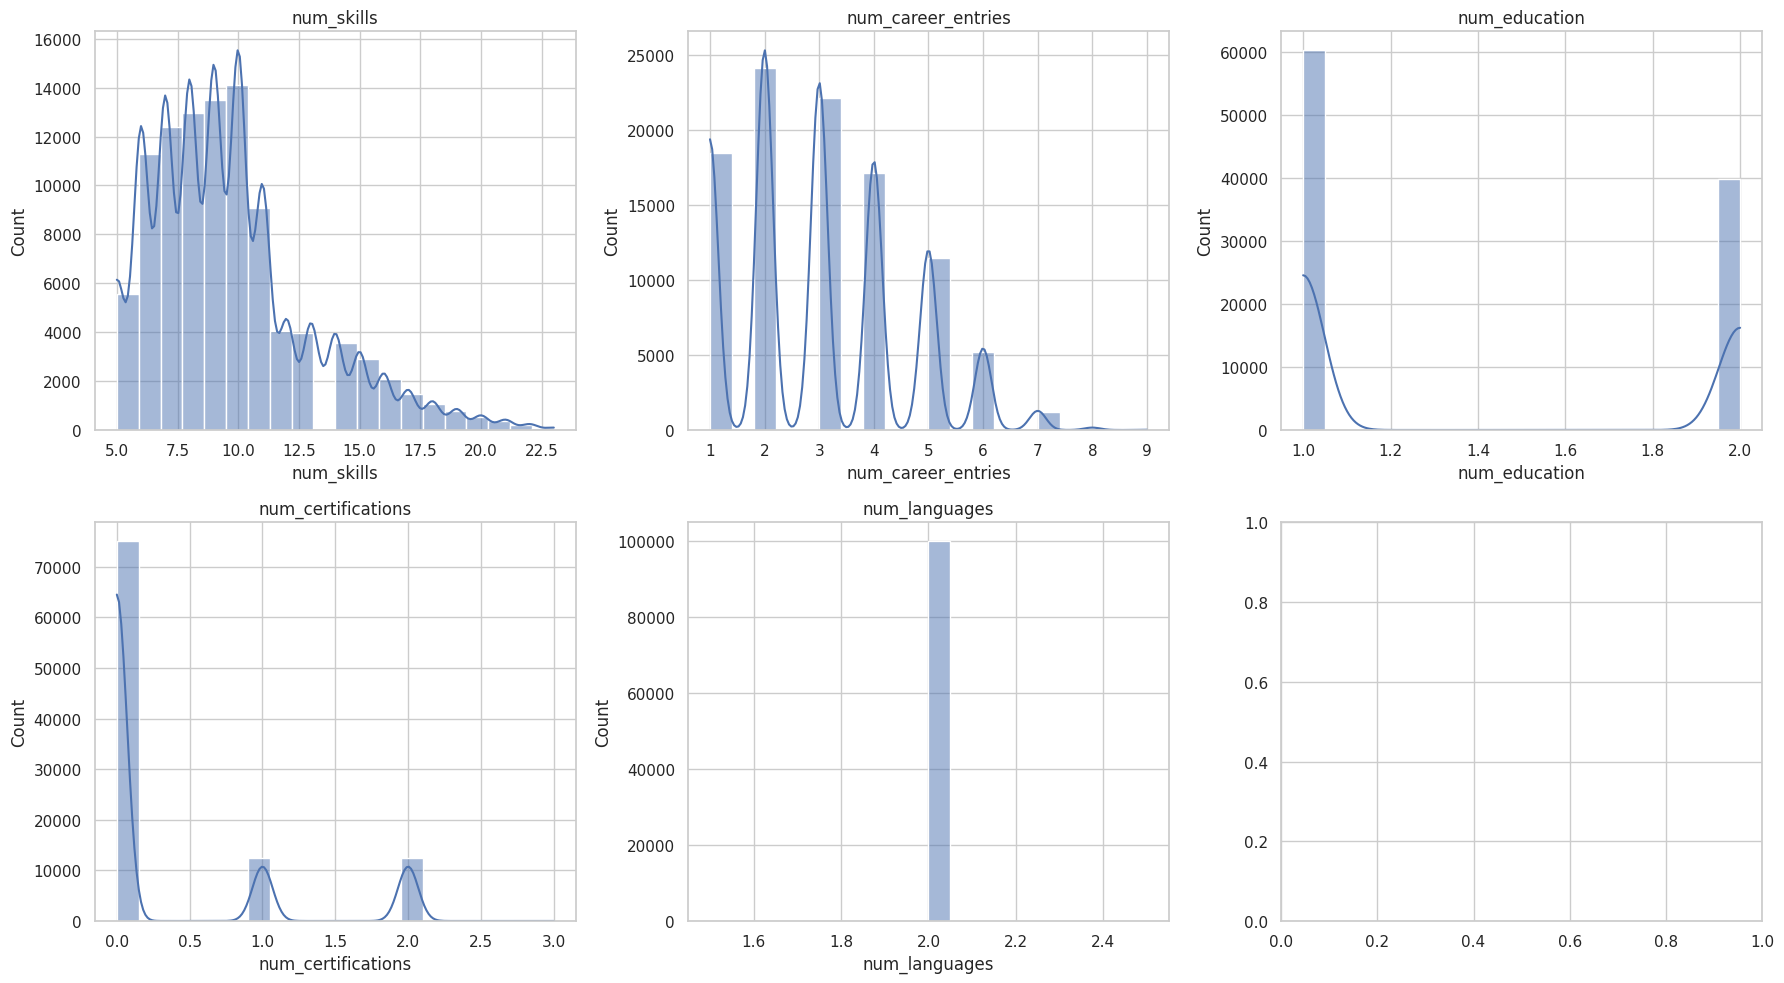

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

cols = counts_df.columns

for ax, col in zip(axes.flatten(), cols):

    sns.histplot(
        counts_df[col],
        bins=20,
        kde=True,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

# H. Years Of Experience Analysis

Purpose:
* Experience distribution
* Outliers
* Junior / Mid / Senior proportions

,years_of_experience
count,100000.000000
mean,7.166319
std,3.824551
min,1.000000
25%,3.900000
50%,6.800000
75%,9.900000
max,16.900000


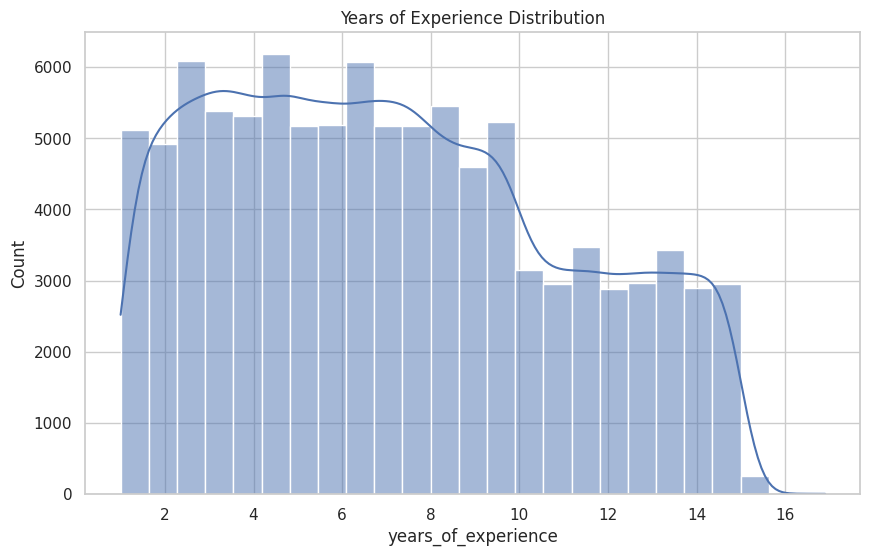

In [ ]:
yoe = flat_df["years_of_experience"]

display(
    yoe.describe()
)

plt.figure(figsize=(10,6))

sns.histplot(
    yoe,
    bins=25,
    kde=True
)

plt.title("Years of Experience Distribution")

plt.show()

In [ ]:
experience_bucket = pd.cut(
    yoe,
    bins=[0,2,5,10,20],
    labels=[
        "Entry",
        "Junior",
        "Mid",
        "Senior"
    ]
)

display(
    experience_bucket
    .value_counts()
)

,count
years_of_experience,
Mid,40942
Junior,26419
Senior,24333
Entry,8306


# I. Headline & Role Analysis

Purpose: Understand
* Most common titles
* Most common role families
* Dataset composition

In [ ]:
top_titles = (
    flat_df["current_title"]
    .value_counts()
    .head(25)
)

display(top_titles)

,count
current_title,
Business Analyst,5833
HR Manager,5830
Mechanical Engineer,5791
Accountant,5764
Project Manager,5754
Customer Support,5750
Operations Manager,5744
Content Writer,5727
Sales Executive,5713


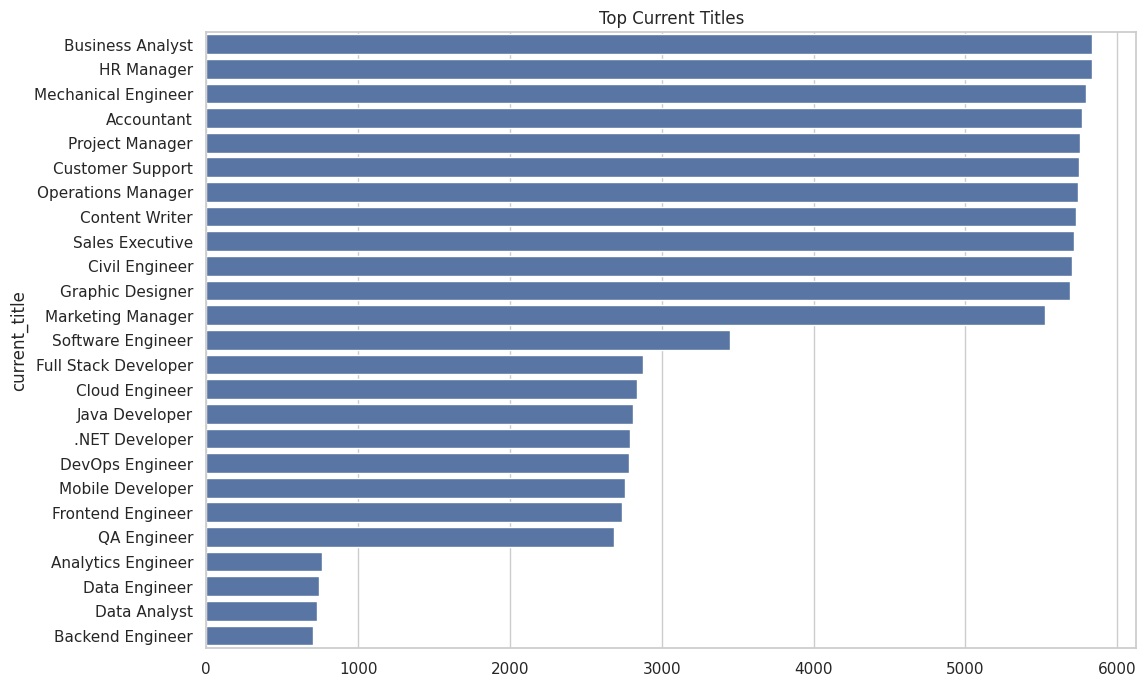

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=top_titles.values,
    y=top_titles.index
)

plt.title("Top Current Titles")

plt.show()

In [ ]:
country_counts = (
    flat_df["country"]
    .value_counts()
)

display(country_counts)

,count
country,
India,75113
USA,9978
Australia,2579
Canada,2506
UK,2472
Germany,2469
Singapore,2453
UAE,2430


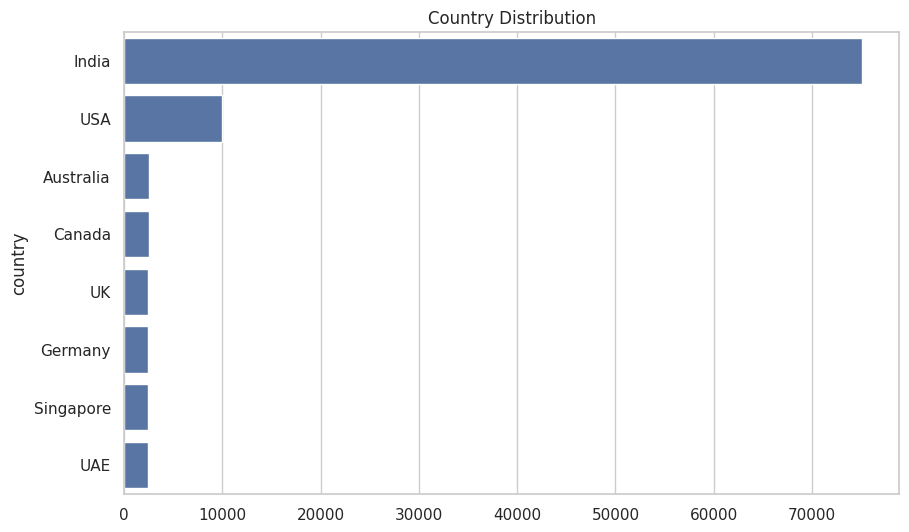

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Country Distribution")

plt.show()

# J. Skill Ecosystem Analysis
Purpose: This fixes your broken Top Skills code.

In [ ]:
from collections import Counter

skill_counter = Counter()

for candidate in candidates:

    for skill in candidate.get("skills", []):

        skill_name = skill.get("name")

        if skill_name:

            skill_counter[skill_name] += 1

top_skills = pd.DataFrame(
    skill_counter.most_common(30),
    columns=[
        "Skill",
        "Count"
    ]
)

display(top_skills)

,Skill,Count
0,HTML,12246
1,Databricks,12244
2,Redux,12222
3,Terraform,12187
4,Angular,12173
5,Figma,12157
6,Salesforce CRM,12157
7,Vue.js,12142
8,Sales,12138
9,Accounting,12136


Unique skills: 133


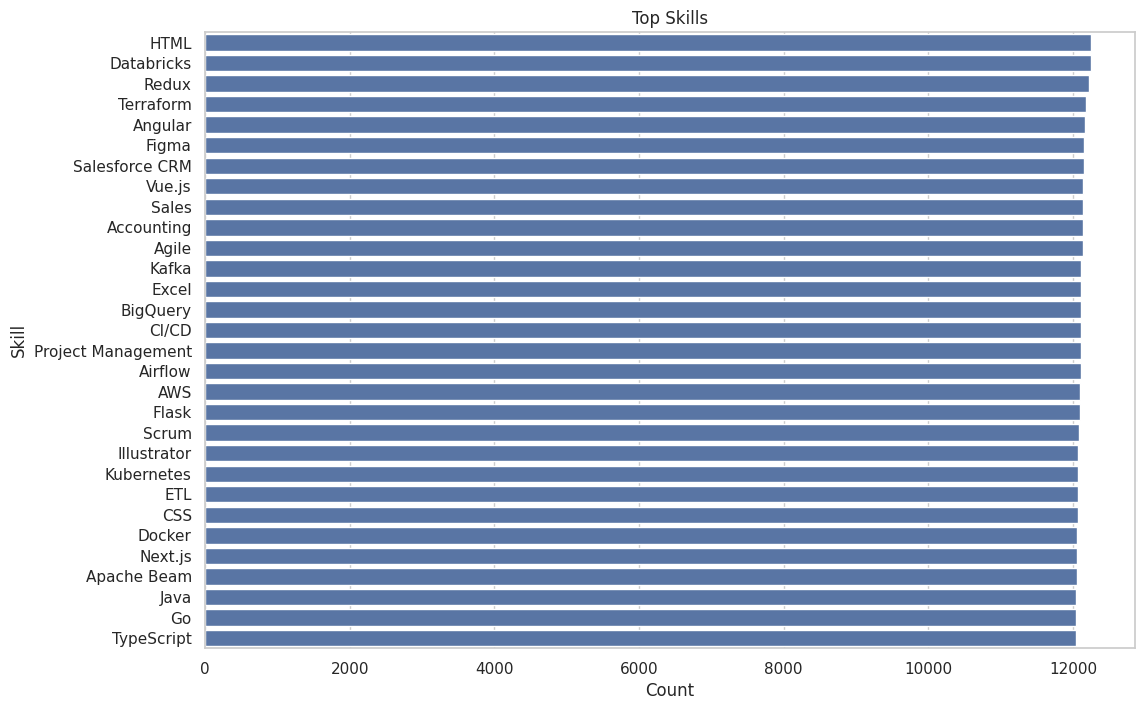

In [ ]:
print(
    "Unique skills:",
    len(skill_counter)
)
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_skills,
    x="Count",
    y="Skill"
)

plt.title("Top Skills")

plt.show()

# K. Skill Quality Analysis
Purpose:

Not just: What skills exist?

But:

* How strong are they?
* How endorsed?
* How long used?

In [ ]:
skill_rows = []

for candidate in candidates:

    for skill in candidate.get("skills", []):

        skill_rows.append({

            "candidate_id":
                candidate["candidate_id"],

            "skill":
                skill.get("name"),

            "proficiency":
                skill.get("proficiency"),

            "endorsements":
                skill.get("endorsements"),

            "duration_months":
                skill.get("duration_months")
        })

skills_df = pd.DataFrame(skill_rows)

print(
    "Total skill records:",
    len(skills_df)
)

display(skills_df.head())

Total skill records: 960302


,candidate_id,skill,proficiency,endorsements,duration_months
0,CAND_0000001,Tailwind,intermediate,3,13
1,CAND_0000001,NLP,advanced,37,26
2,CAND_0000001,Image Classification,advanced,7,40
3,CAND_0000001,Fine-tuning LLMs,advanced,21,36
4,CAND_0000001,Weights & Biases,intermediate,13,30


,count
proficiency,
intermediate,470309
beginner,379097
advanced,109585
expert,1311


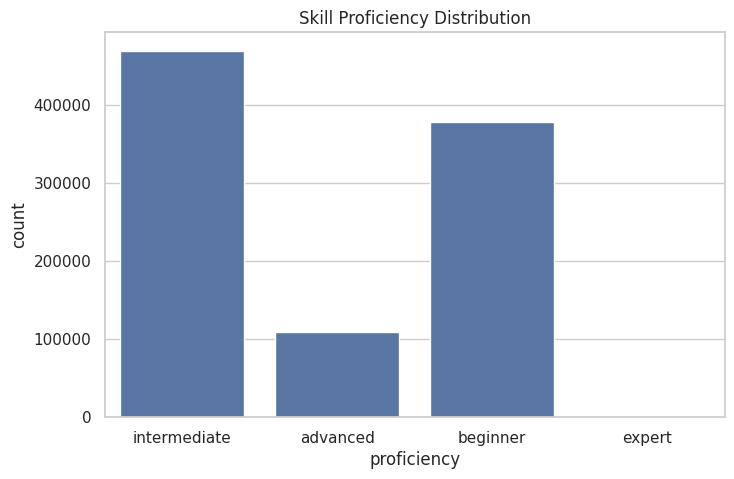

In [ ]:
display(
    skills_df["proficiency"]
    .value_counts()
)
plt.figure(figsize=(8,5))

sns.countplot(
    data=skills_df,
    x="proficiency"
)

plt.title("Skill Proficiency Distribution")

plt.show()

,endorsements
count,960302.000000
mean,8.970884
std,9.082405
min,0.000000
25%,3.000000
50%,8.000000
75%,12.000000
max,60.000000


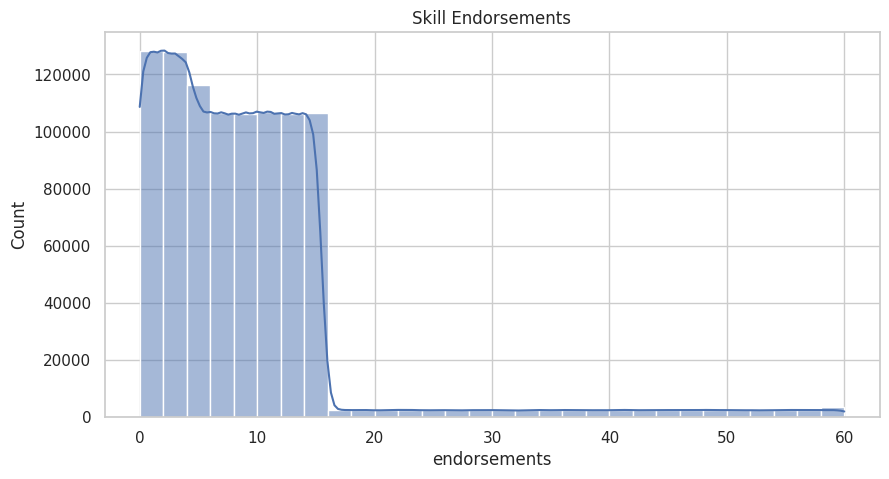

In [ ]:
display(
    skills_df["endorsements"]
    .describe()
)
plt.figure(figsize=(10,5))

sns.histplot(
    skills_df["endorsements"],
    bins=30,
    kde=True
)

plt.title("Skill Endorsements")

plt.show()

,duration_months
count,960302.000000
mean,18.028557
std,11.327091
min,0.000000
25%,10.000000
50%,16.000000
75%,25.000000
max,96.000000


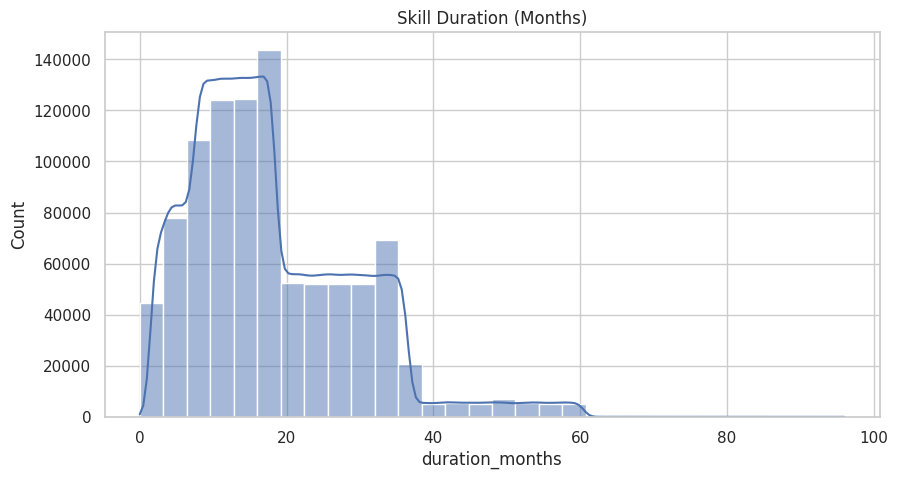

In [ ]:
display(
    skills_df["duration_months"]
    .describe()
)
plt.figure(figsize=(10,5))

sns.histplot(
    skills_df["duration_months"],
    bins=30,
    kde=True
)

plt.title("Skill Duration (Months)")

plt.show()

# L. Behavioral Signal Exploration

Purpose: Understand
* Who is actually hireable?
* Who is active?
* Who is dead?
* Which signals are useful?

,profile_completeness_score,recruiter_response_rate,avg_response_time_hours,connection_count,endorsements_received,notice_period_days,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,56.758180,0.436574,132.702744,345.664890,30.068570,87.385800,9.619230,117.543800,7.658700,0.619510,-0.403604
std,17.274069,0.214122,75.238241,208.145694,20.242847,36.589628,17.761394,92.825891,5.921436,0.170662,0.732439
min,25.000000,0.020000,2.100000,10.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.300000,-1.000000
25%,42.200000,0.250000,68.300000,174.000000,14.000000,60.000000,-1.000000,52.000000,3.000000,0.480000,-1.000000
50%,56.800000,0.440000,129.900000,335.000000,28.000000,90.000000,-1.000000,105.000000,7.000000,0.620000,-1.000000
75%,71.600000,0.620000,193.300000,497.000000,43.000000,120.000000,16.700000,158.000000,11.000000,0.760000,0.400000
max,99.900000,0.950000,280.000000,1898.000000,242.000000,150.000000,96.900000,1490.000000,80.000000,1.000000,0.930000


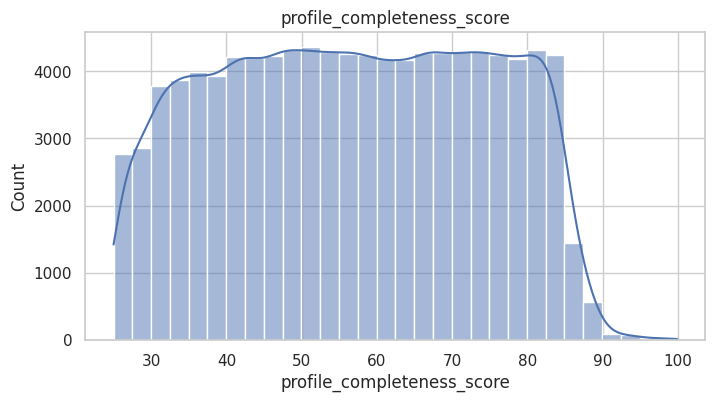

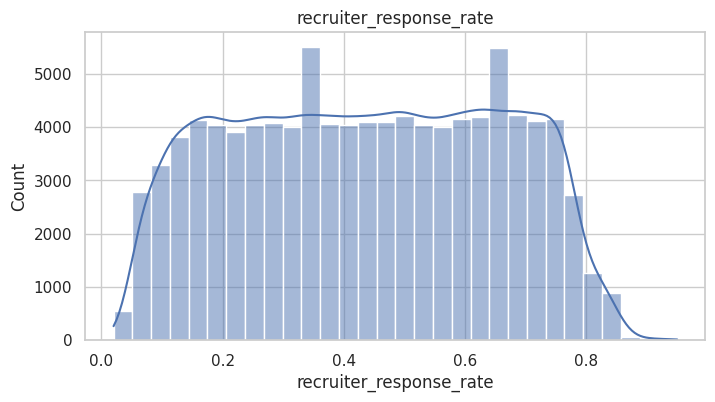

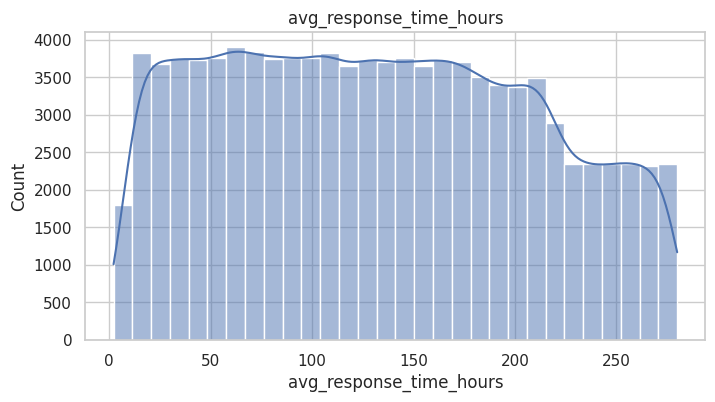

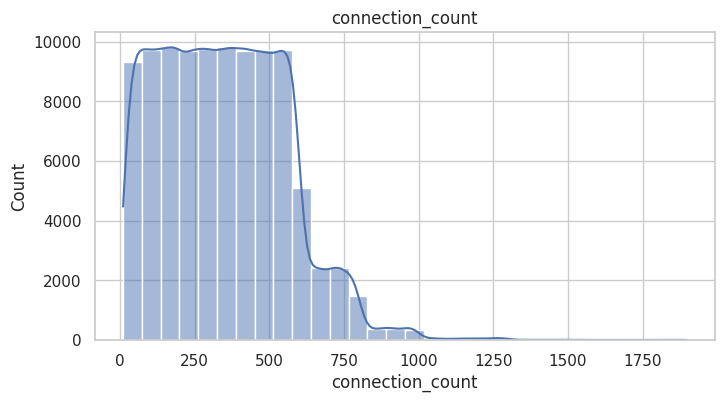

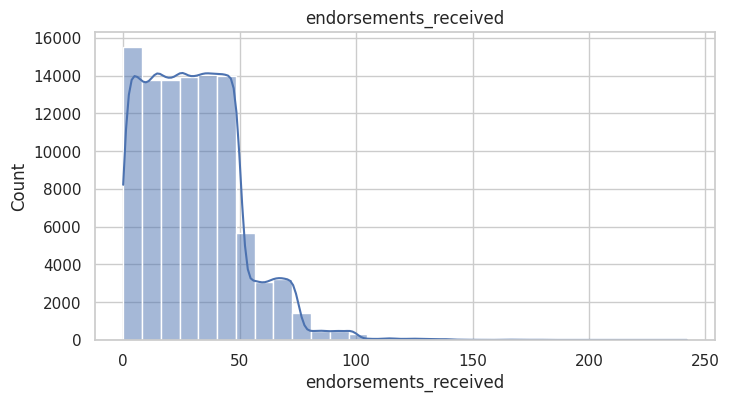

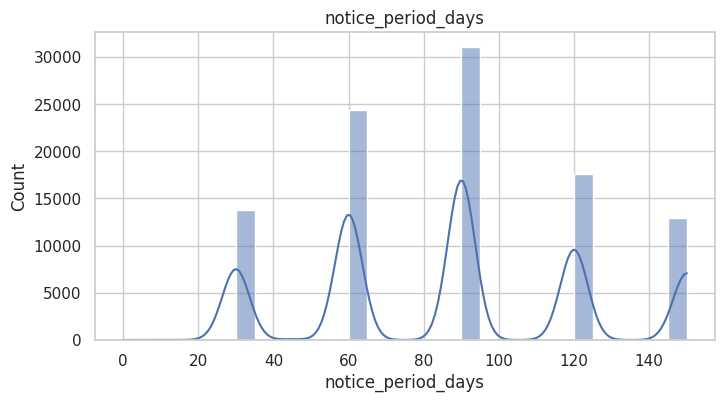

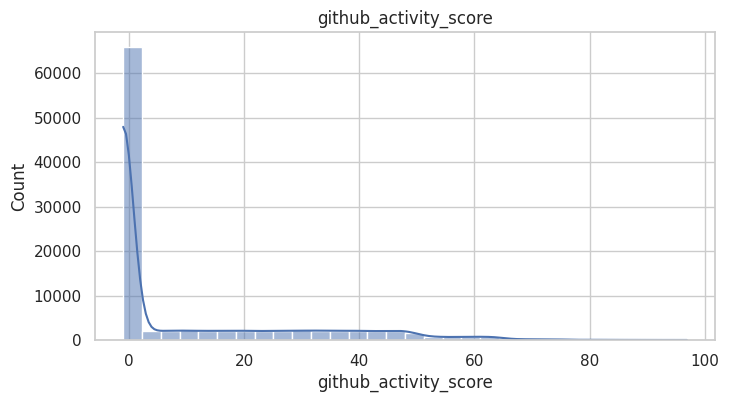

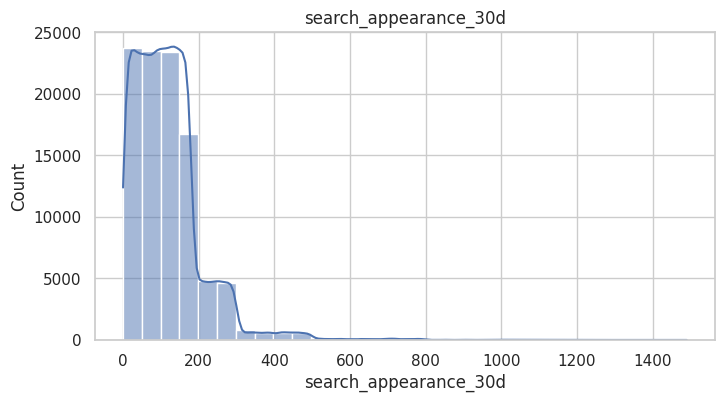

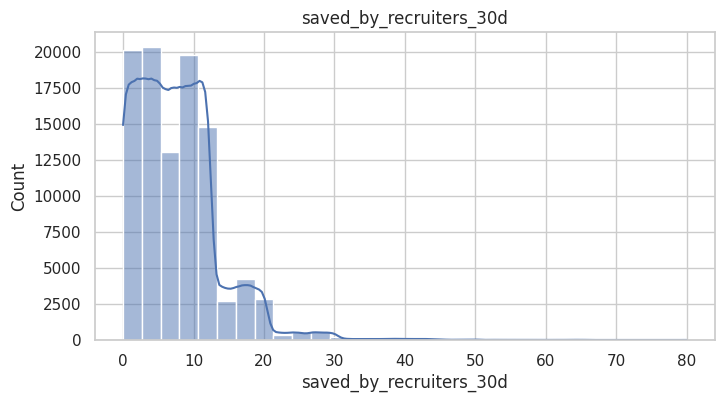

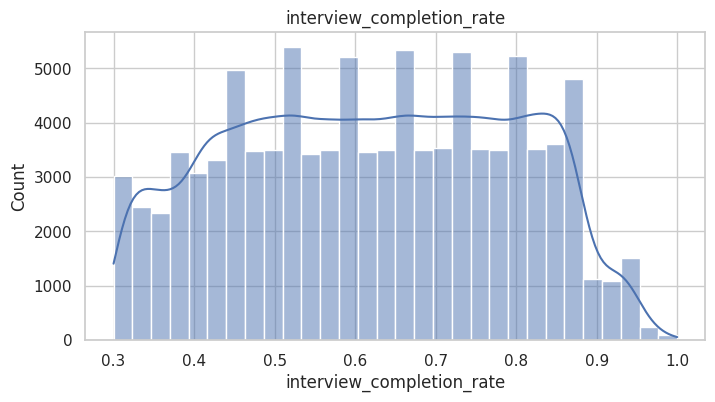

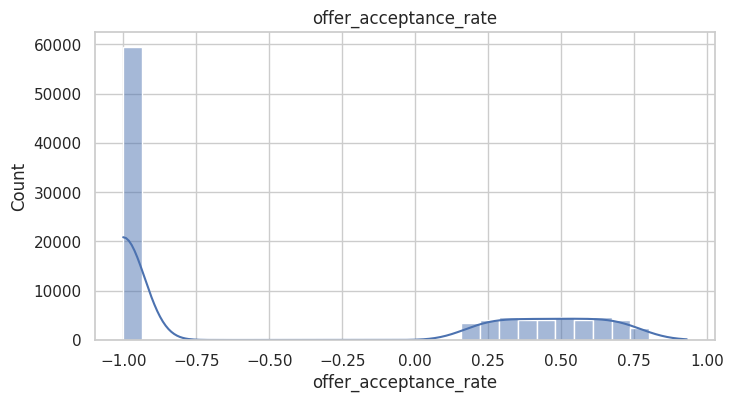

In [ ]:
behavior_cols = [
    "profile_completeness_score",
    "recruiter_response_rate",
    "avg_response_time_hours",
    "connection_count",
    "endorsements_received",
    "notice_period_days",
    "github_activity_score",
    "search_appearance_30d",
    "saved_by_recruiters_30d",
    "interview_completion_rate",
    "offer_acceptance_rate"
]

display(
    flat_df[behavior_cols]
    .describe()
)
for col in behavior_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        flat_df[col],
        bins=30,
        kde=True
    )

    plt.title(col)

    plt.show()

# M. Hidden Missing Value Analysis

Purpose

* github_activity_score = -1
* offer_acceptance_rate = -1

In [ ]:
sentinel_report = []

for col in behavior_cols:

    if flat_df[col].dtype in ["int64","float64"]:

        sentinel_report.append({

            "column": col,

            "negative_one_count":
                (flat_df[col] == -1).sum(),

            "negative_one_percent":
                round(
                    ((flat_df[col] == -1).mean()) * 100,
                    2
                )
        })

sentinel_df = pd.DataFrame(sentinel_report)

display(
    sentinel_df.sort_values(
        "negative_one_percent",
        ascending=False
    )
)
eda_df = flat_df.copy()

eda_df["github_activity_score"] = (
    eda_df["github_activity_score"]
    .replace(-1, np.nan)
)

eda_df["offer_acceptance_rate"] = (
    eda_df["offer_acceptance_rate"]
    .replace(-1, np.nan)
)

,column,negative_one_count,negative_one_percent
6,github_activity_score,64637,64.64
10,offer_acceptance_rate,59554,59.55
0,profile_completeness_score,0,0.00
2,avg_response_time_hours,0,0.00
1,recruiter_response_rate,0,0.00
4,endorsements_received,0,0.00
3,connection_count,0,0.00
5,notice_period_days,0,0.00
7,search_appearance_30d,0,0.00
8,saved_by_recruiters_30d,0,0.00


# N. Activity & Engagement Analysis

Purpose

Recruiters care about:
* Who gets viewed?
* Who gets saved?
* Who gets searched?

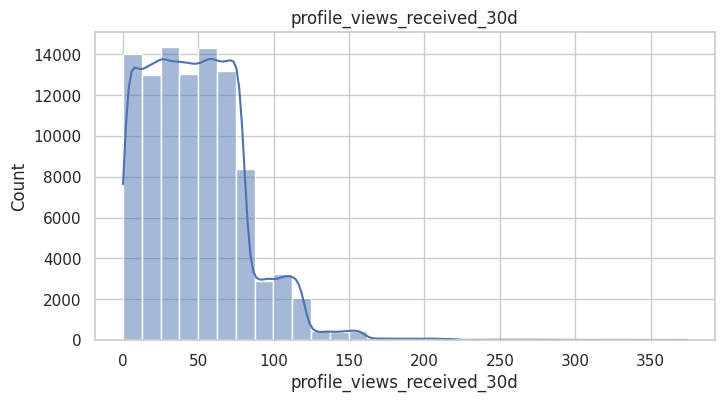

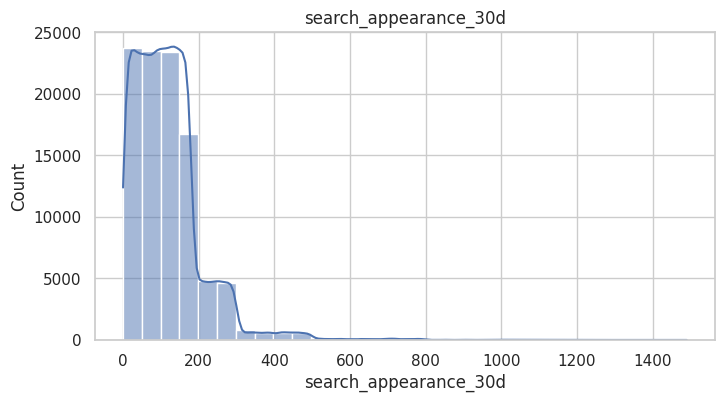

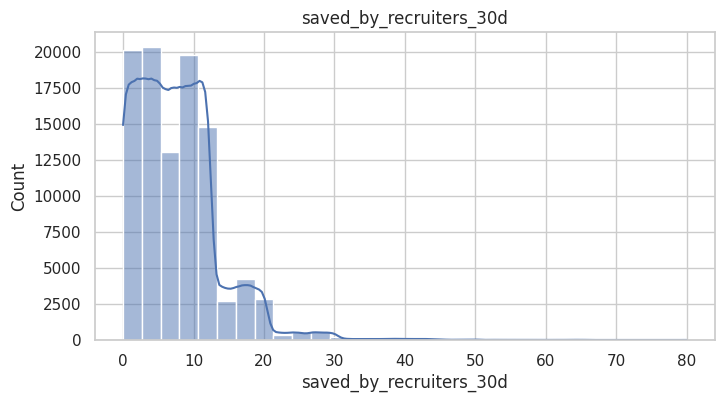


 profile_views_received_30d
99th percentile: 142.0

 search_appearance_30d
99th percentile: 459.0

 saved_by_recruiters_30d
99th percentile: 28.0


In [ ]:
engagement_cols = [
    "profile_views_received_30d",
    "search_appearance_30d",
    "saved_by_recruiters_30d"
]

for col in engagement_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        flat_df[col],
        bins=30,
        kde=True
    )

    plt.title(col)

    plt.show()

for col in engagement_cols:

    threshold = flat_df[col].quantile(0.99)

    print("\n", col)

    print("99th percentile:", threshold)

# O. Recency Analysis
Purpose: The README keeps hinting that inactive candidates matter.

In [ ]:
flat_df["signup_date"] = pd.to_datetime(
    flat_df["signup_date"]
)

flat_df["last_active_date"] = pd.to_datetime(
    flat_df["last_active_date"]
)

REFERENCE_DATE = flat_df[
    "last_active_date"
].max()

flat_df["days_since_active"] = (
    REFERENCE_DATE -
    flat_df["last_active_date"]
).dt.days

display(
    flat_df["days_since_active"]
    .describe()
)

,days_since_active
count,100000.000000
mean,108.723890
std,66.588459
min,0.000000
25%,52.000000
50%,105.000000
75%,162.000000
max,240.000000


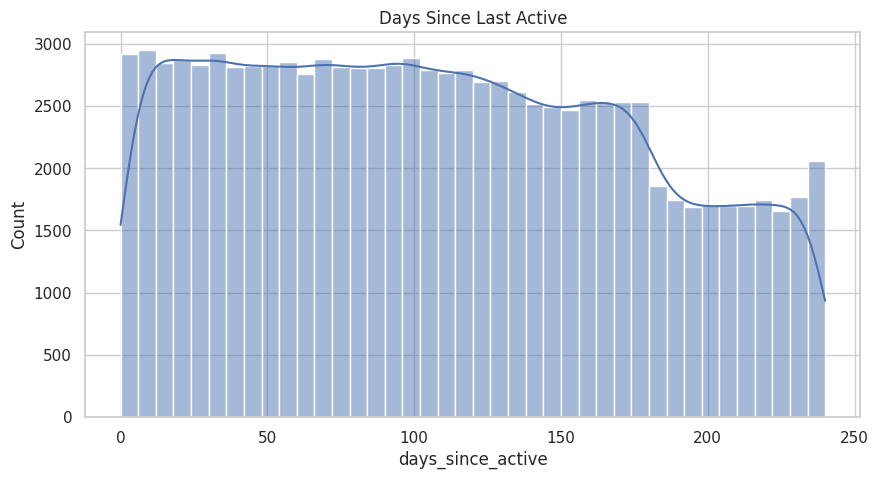

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    flat_df["days_since_active"],
    bins=40,
    kde=True
)

plt.title("Days Since Last Active")

plt.show()

In [ ]:
print(
    "Active (<=30 days):",
    (flat_df["days_since_active"] <= 30).sum()
)

print(
    "Dormant (>180 days):",
    (flat_df["days_since_active"] > 180).sum()
)

Active (<=30 days): 14886
Dormant (>180 days): 17165


# P. Open-To-Work Analysis
Purpose: This is one of the most important recruiter signals.

In [ ]:
display(
    flat_df["open_to_work_flag"]
    .value_counts()
)

,count
open_to_work_flag,
False,64661
True,35339


In [ ]:
(
    flat_df["open_to_work_flag"]
    .value_counts(normalize=True)
    * 100
).round(2)

,proportion
open_to_work_flag,
False,64.66
True,35.34


In [ ]:
comparison = flat_df.groupby(
    "open_to_work_flag"
)[
    [
        "search_appearance_30d",
        "saved_by_recruiters_30d",
        "interview_completion_rate"
    ]
].mean()

display(comparison)

,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate
open_to_work_flag,,,
False,112.564111,7.371197,0.616200
True,126.655310,8.184753,0.625566


# Q. Assessment Score Analysis
Purpose: One of the most important sections.

Remember: Skill Presence ≠ Skill Trust

In [ ]:
assessment_rows = []

for candidate in candidates:

    assessments = (
        candidate
        .get("redrob_signals", {})
        .get("skill_assessment_scores", {})
    )

    for skill, score in assessments.items():

        assessment_rows.append({

            "candidate_id":
                candidate["candidate_id"],

            "skill":
                skill,

            "score":
                score
        })

assessments_df = pd.DataFrame(
    assessment_rows
)

print(
    "Assessment records:",
    len(assessments_df)
)

display(
    assessments_df.head()
)

Assessment records: 35895


,candidate_id,skill,score
0,CAND_0000001,NLP,38.8
1,CAND_0000001,Image Classification,64.8
2,CAND_0000001,Fine-tuning LLMs,41.6
3,CAND_0000001,Speech Recognition,53.7
4,CAND_0000010,GANs,53.3


In [ ]:
display(
    assessments_df["score"]
    .describe()
)

,score
count,35895.000000
mean,52.919109
std,15.778763
min,20.000000
25%,40.300000
50%,53.100000
75%,65.900000
max,97.300000


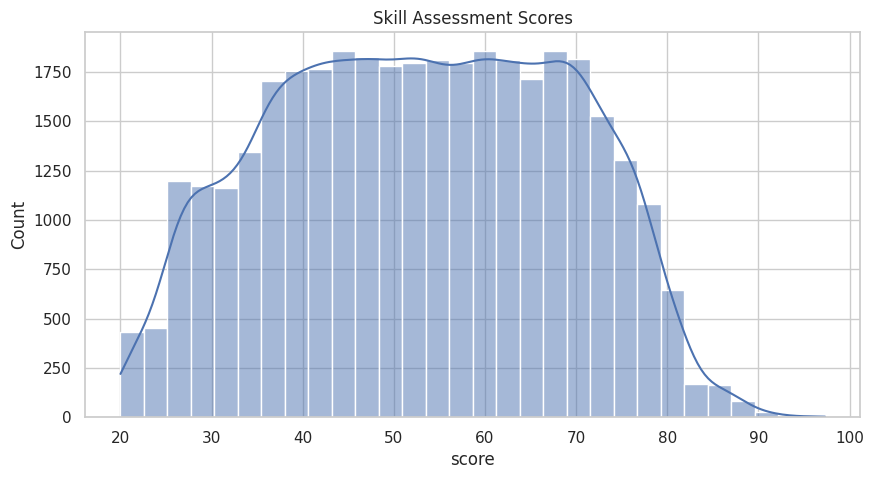

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    assessments_df["score"],
    bins=30,
    kde=True
)

plt.title("Skill Assessment Scores")

plt.show()

# R. Education Analysis
Purpose: Understand
* Education quality
* Tier distribution
* Degree distribution
* Field distribution

In [ ]:
education_rows = []

for candidate in candidates:

    for edu in candidate.get("education", []):

        education_rows.append({

            "candidate_id":
                candidate["candidate_id"],

            "institution":
                edu.get("institution"),

            "degree":
                edu.get("degree"),

            "field":
                edu.get("field_of_study"),

            "tier":
                edu.get("tier"),

            "start_year":
                edu.get("start_year"),

            "end_year":
                edu.get("end_year")
        })

education_df = pd.DataFrame(
    education_rows
)

print(
    "Education Records:",
    len(education_df)
)

display(
    education_df.head()
)

Education Records: 139778


,candidate_id,institution,degree,field,tier,start_year,end_year
0,CAND_0000001,Lovely Professional University,B.E.,Computer Science,tier_3,2017,2020
1,CAND_0000002,Local Engineering College,B.Sc,Mathematics,tier_4,2007,2011
2,CAND_0000003,Local Engineering College,M.E.,Chemical Engineering,tier_4,2005,2010
3,CAND_0000003,Chandigarh University,M.Sc,Information Technology,tier_3,2017,2021
4,CAND_0000004,Local Engineering College,B.Tech,Machine Learning,tier_4,2015,2019


,count
tier,
tier_3,53220
tier_4,51885
tier_2,27821
tier_1,6852


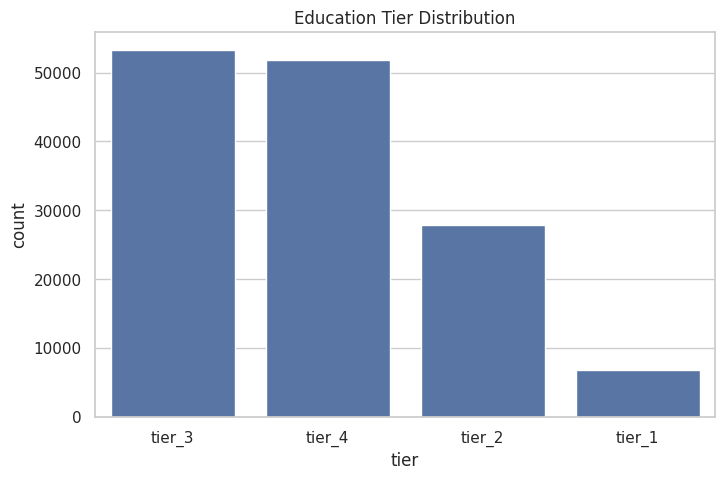

In [ ]:
display(
    education_df["tier"]
    .value_counts()
)
plt.figure(figsize=(8,5))

sns.countplot(
    data=education_df,
    x="tier"
)

plt.title("Education Tier Distribution")

plt.show()

In [ ]:
top_degrees = (
    education_df["degree"]
    .value_counts()
    .head(20)
)

display(top_degrees)

top_fields = (
    education_df["field"]
    .value_counts()
    .head(20)
)

display(top_fields)

,count
degree,
M.E.,17650
M.S.,17604
M.Sc,17562
M.Tech,17535
Ph.D,17526
B.Tech,17465
B.E.,17259
B.Sc,17177


,count
field,
Information Technology,12328
Data Science,12222
Machine Learning,12216
Computer Engineering,12114
Artificial Intelligence,12009
Computer Science,11868
Statistics,6762
Chemical Engineering,6740
Physics,6726


# S. Career History Analysis
Purpose: Understand
* Job count
* Career span
* Industry patterns
* Company sizes

In [ ]:
career_rows = []

for candidate in candidates:

    for job in candidate.get("career_history", []):

        career_rows.append({

            "candidate_id":
                candidate["candidate_id"],

            "company":
                job.get("company"),

            "title":
                job.get("title"),

            "industry":
                job.get("industry"),

            "company_size":
                job.get("company_size"),

            "duration_months":
                job.get("duration_months"),

            "is_current":
                job.get("is_current")
        })

career_df = pd.DataFrame(
    career_rows
)

print(
    "Career Records:",
    len(career_df)
)

display(
    career_df.head()
)

Career Records: 300171


,candidate_id,company,title,industry,company_size,duration_months,is_current
0,CAND_0000001,Mindtree,Backend Engineer,IT Services,10001+,27,True
1,CAND_0000001,Dunder Mifflin,Analytics Engineer,Paper Products,201-500,55,False
2,CAND_0000002,Wipro,Operations Manager,IT Services,10001+,43,True
3,CAND_0000002,Wipro,Operations Manager,IT Services,10001+,14,False
4,CAND_0000002,Acme Corp,Marketing Manager,Manufacturing,201-500,54,False


In [ ]:
top_industries = (
    career_df["industry"]
    .value_counts()
    .head(20)
)

display(top_industries)

display(
    career_df["company_size"]
    .value_counts()
)

,count
industry,
IT Services,88077
Software,70746
Manufacturing,70541
Conglomerate,23556
Paper Products,23416
Fintech,6513
Food Delivery,5902
E-commerce,3644
Consulting,2871


,count
company_size,
10001+,118627
1001-5000,55022
201-500,47276
51-200,23978
11-50,23754
501-1000,23550
5001-10000,7964


,duration_months
count,300171.000000
mean,28.236229
std,12.489886
min,6.000000
25%,18.000000
50%,27.000000
75%,38.000000
max,228.000000


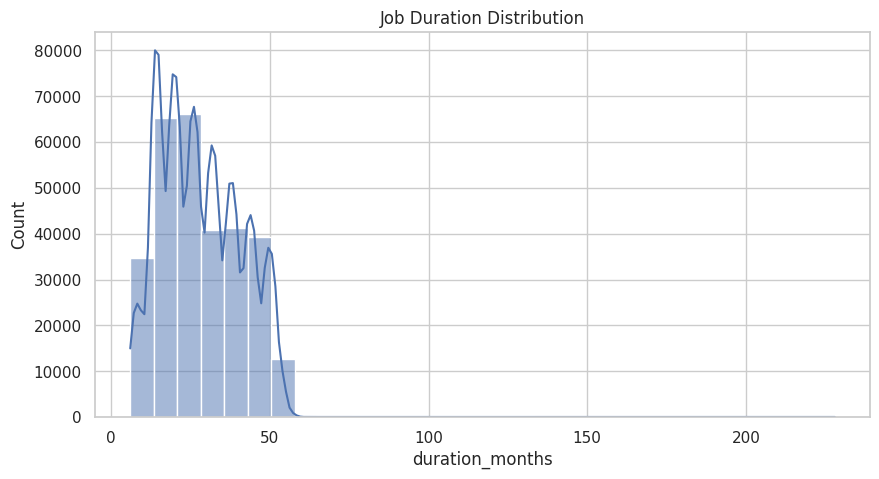

In [ ]:
display(
    career_df["duration_months"]
    .describe()
)

plt.figure(figsize=(10,5))

sns.histplot(
    career_df["duration_months"],
    bins=30,
    kde=True
)

plt.title("Job Duration Distribution")

plt.show()

# T. Verification & Trust Analysis
Purpose: These are subtle recruiter trust signals.

In [ ]:
verification_cols = [
    "verified_email",
    "verified_phone",
    "linkedin_connected"
]

for col in verification_cols:

    print("\n")
    print(col)

    display(
        flat_df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )



verified_email


,proportion
verified_email,
True,72.0
False,28.0




verified_phone


,proportion
verified_phone,
True,61.79
False,38.21




linkedin_connected


,proportion
linkedin_connected,
False,64.0
True,36.0


In [ ]:
flat_df["verification_score"] = (

    flat_df["verified_email"].astype(int)

    +

    flat_df["verified_phone"].astype(int)

    +

    flat_df["linkedin_connected"].astype(int)

)

display(
    flat_df["verification_score"]
    .value_counts()
)

,count
verification_score,
2,44077
1,32476
3,16387
0,7060


# U. Correlation Analysis
Purpose:
This is where hidden relationships appear.

In [ ]:
corr_cols = [

    "profile_completeness_score",

    "recruiter_response_rate",

    "avg_response_time_hours",

    "connection_count",

    "endorsements_received",

    "github_activity_score",

    "search_appearance_30d",

    "saved_by_recruiters_30d",

    "interview_completion_rate",

    "offer_acceptance_rate",

    "years_of_experience"
]

corr_df = eda_df[corr_cols]

corr = corr_df.corr()

display(corr)

,profile_completeness_score,recruiter_response_rate,avg_response_time_hours,connection_count,endorsements_received,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate,years_of_experience
profile_completeness_score,1.000000,0.023116,-0.043147,0.062900,0.078141,0.068566,0.110880,0.097179,0.041293,0.040486,-0.051043
recruiter_response_rate,0.023116,1.000000,-0.037826,0.053721,0.063618,0.054538,0.084197,0.084060,0.036047,0.030276,-0.041180
avg_response_time_hours,-0.043147,-0.037826,1.000000,-0.084809,-0.105660,-0.091988,-0.137599,-0.127828,-0.062315,-0.053526,0.070581
connection_count,0.062900,0.053721,-0.084809,1.000000,0.155024,0.124393,0.204520,0.180022,0.080879,0.074990,-0.095559
endorsements_received,0.078141,0.063618,-0.105660,0.155024,1.000000,0.163377,0.262825,0.233320,0.107725,0.096305,-0.125030
github_activity_score,0.068566,0.054538,-0.091988,0.124393,0.163377,1.000000,0.198400,0.181759,0.093126,0.058978,-0.093019
search_appearance_30d,0.110880,0.084197,-0.137599,0.204520,0.262825,0.198400,1.000000,0.314029,0.139394,0.113949,-0.143471
saved_by_recruiters_30d,0.097179,0.084060,-0.127828,0.180022,0.233320,0.181759,0.314029,1.000000,0.127463,0.101256,-0.137175
interview_completion_rate,0.041293,0.036047,-0.062315,0.080879,0.107725,0.093126,0.139394,0.127463,1.000000,0.047428,-0.083855
offer_acceptance_rate,0.040486,0.030276,-0.053526,0.074990,0.096305,0.058978,0.113949,0.101256,0.047428,1.000000,-0.055734


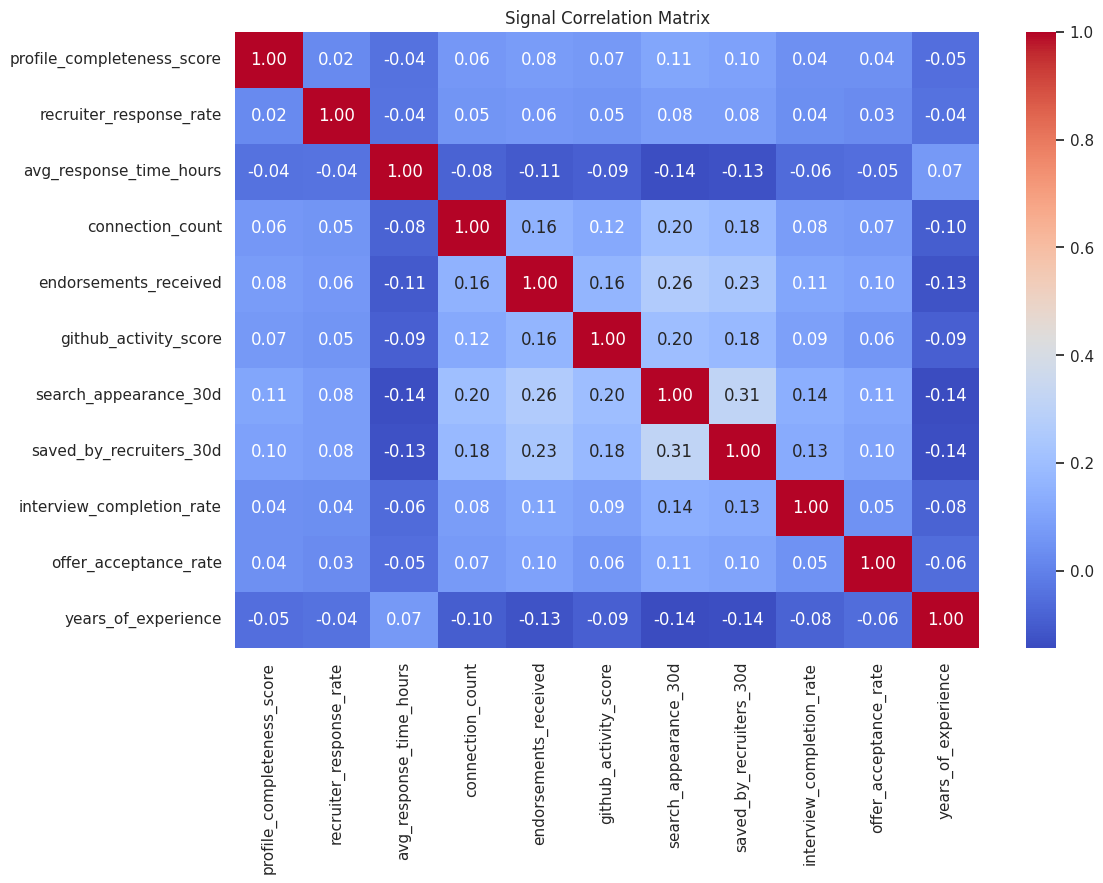

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Signal Correlation Matrix")

plt.show()

In [ ]:
corr_pairs = (
    corr.unstack()
    .sort_values(
        ascending=False
    )
)

corr_pairs = corr_pairs[
    corr_pairs < 1
]

display(
    corr_pairs.head(20)
)

search_appearance_30d      saved_by_recruiters_30d      0.314029
saved_by_recruiters_30d    search_appearance_30d        0.314029
endorsements_received      search_appearance_30d        0.262825
search_appearance_30d      endorsements_received        0.262825
saved_by_recruiters_30d    endorsements_received        0.233320
endorsements_received      saved_by_recruiters_30d      0.233320
connection_count           search_appearance_30d        0.204520
search_appearance_30d      connection_count             0.204520
                           github_activity_score        0.198400
github_activity_score      search_appearance_30d        0.198400
                           saved_by_recruiters_30d      0.181759
saved_by_recruiters_30d    github_activity_score        0.181759
                           connection_count             0.180022
connection_count           saved_by_recruiters_30d      0.180022
endorsements_received      github_activity_score        0.163377
github_activity_score      endorsements_received        0.163377
endorsements_received      connection_count             0.155024
connection_count           endorsements_received        0.155024
interview_completion_rate  search_appearance_30d        0.139394
search_appearance_30d      interview_completion_rate    0.139394
dtype: float64

# V. Candidate Archetypes
Purpose: Don't trust statistics alone.

Read actual profiles.

In [ ]:
display(

    flat_df

    .sort_values(
        "github_activity_score",
        ascending=False
    )

    [[
        "candidate_id",
        "headline",
        "github_activity_score"
    ]]

    .head(10)
)

,candidate_id,headline,github_activity_score
2024,CAND_0002025,Senior AI Engineer | Building AI-native search...,96.9
16162,CAND_0016163,Applied ML Engineer | Applied ML | Building in...,95.0
18498,CAND_0018499,Senior Machine Learning Engineer | Building AI...,94.8
51614,CAND_0051615,Search Engineer | Applied ML | Building intell...,94.6
66998,CAND_0066999,Recommendation Systems Engineer | Applied ML |...,94.4
18721,CAND_0018722,"Recommendation Systems Engineer | Search, Rank...",94.3
17959,CAND_0017960,"Recommendation Systems Engineer | ML, NLP, Rec...",92.4
49537,CAND_0049538,"Applied ML Engineer | Search, Ranking & Retrieval",90.8
47720,CAND_0047721,"Senior Data Scientist | ML, NLP, Recommendatio...",90.1
7410,CAND_0007411,Senior Machine Learning Engineer | Production ...,89.5


In [ ]:
display(

    flat_df

    .sort_values(
        "interview_completion_rate",
        ascending=False
    )

    [[
        "candidate_id",
        "headline",
        "interview_completion_rate"
    ]]

    .head(10)
)

,candidate_id,headline,interview_completion_rate
32178,CAND_0032179,Computer Vision Engineer | 6.4 yrs in analytic...,1.0
1706,CAND_0001707,Data Scientist | Data Science & ML enthusiast,1.0
71431,CAND_0071432,Data Scientist | Data Science & ML enthusiast,1.0
37159,CAND_0037160,Data Scientist | Building ML-powered solutions,1.0
9836,CAND_0009837,"Senior Data Scientist | Search, Ranking & Retr...",1.0
24877,CAND_0024878,AI Specialist | Building ML-powered solutions,1.0
78855,CAND_0078856,AI Specialist | 3.3 yrs in analytics & ML,1.0
87629,CAND_0087630,AI Engineer | Applied ML | Building intelligen...,1.0
44261,CAND_0044262,Data Scientist | 6.9 yrs in analytics & ML,1.0
38205,CAND_0038206,Data Scientist | Data Science & ML enthusiast,1.0


In [ ]:
import pprint

def inspect_candidate(candidate_id):

    for candidate in candidates:

        if candidate["candidate_id"] == candidate_id:

            pprint.pprint(candidate)

            return

    print("Candidate not found")

# W. Honeypot Recon (Pre-M4)
Purpose:
* NOT detection.
* Just exploration.
* Find weird profiles.

In [ ]:
display(

    flat_df

    .sort_values(
        "years_of_experience",
        ascending=False
    )

    .head(10)
)

,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate,verified_email,verified_phone,linkedin_connected,days_since_active,verification_score
55991,CAND_0055992,Deepak Bansal,"AI Engineer | Search, Ranking & Retrieval",Machine learning engineer with 6.8 years of ex...,Sydney,Australia,16.9,AI Engineer,CRED,1001-5000,...,65.3,451,57,0.91,0.74,True,True,True,60,3
91533,CAND_0091534,Dhruv Dutta,"AI Engineer | ML, NLP, Recommendation Systems",Machine learning engineer with 7.2 years of ex...,"Gurgaon, Haryana",India,16.6,AI Engineer,Flipkart,10001+,...,66.0,713,49,0.81,0.35,True,True,True,22,3
71114,CAND_0071115,Tanya Shah,"Recommendation Systems Engineer | ML, NLP, Rec...",Machine learning engineer with 5.8 years of ex...,"Ahmedabad, Gujarat",India,16.5,Recommendation Systems Engineer,Meta,10001+,...,31.4,748,29,0.57,-1.00,True,True,False,44,2
39753,CAND_0039754,Mira Banerjee,Senior Applied Scientist | Building AI-native ...,Senior AI engineer with 8.3 years of hands-on ...,"Indore, Madhya Pradesh",India,16.2,Senior Applied Scientist,Meta,10001+,...,77.5,541,51,0.98,0.55,True,True,True,13,3
93330,CAND_0093331,Kiara Menon,NLP Engineer | Applied ML | Building intellige...,Machine learning engineer with 7.2 years of ex...,"Kochi, Kerala",India,16.1,NLP Engineer,Genpact AI,10001+,...,74.0,897,30,0.98,0.88,True,True,False,49,2
95618,CAND_0095619,Vivaan Dalal,NLP Engineer | Applied ML | Building intellige...,Machine learning engineer with 4.2 years of ex...,"Mumbai, Maharashtra",India,15.6,NLP Engineer,Nykaa,1001-5000,...,29.7,1018,55,0.93,0.64,True,True,True,41,3
10769,CAND_0010770,Ved Mittal,"Recommendation Systems Engineer | ML, NLP, Rec...",Machine learning engineer with 7.2 years of ex...,"Kolkata, West Bengal",India,15.2,Recommendation Systems Engineer,Aganitha,51-200,...,-1.0,814,12,0.82,0.84,False,False,True,22,1
11255,CAND_0011256,Pooja Saxena,Sales Executive | 15.0+ yrs experience,Professional with 15.0+ years of experience. M...,Seattle,USA,15.0,Sales Executive,TCS,10001+,...,-1.0,17,3,0.75,0.19,True,True,False,124,2
10406,CAND_0010407,Saanvi Mittal,Content Writer | Helping teams scale,Professional with 15.0+ years of experience. I...,"Indore, Madhya Pradesh",India,15.0,Content Writer,Infosys,10001+,...,-1.0,94,7,0.48,-1.00,False,True,True,171,2
11203,CAND_0011204,Tanvi Mukherjee,Business Analyst | Helping teams scale,Professional with 15.0+ years of experience. I...,"Vizag, Andhra Pradesh",India,15.0,Business Analyst,Wipro,10001+,...,-1.0,176,5,0.65,-1.00,False,True,False,168,1


In [ ]:
suspicious = flat_df[

    (flat_df["profile_completeness_score"] > 80)

    &

    (flat_df["github_activity_score"] == -1)

    &

    (flat_df["search_appearance_30d"] == 0)

]

print(
    "Suspicious Profiles:",
    len(suspicious)
)

display(
    suspicious.head()
)

Suspicious Profiles: 31


,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate,verified_email,verified_phone,linkedin_connected,days_since_active,verification_score
1036,CAND_0001037,Advik Joshi,Civil Engineer | Driving business outcomes,Professional with 8.8+ years of experience. My...,"Indore, Madhya Pradesh",India,8.8,Civil Engineer,Dunder Mifflin,201-500,...,-1.0,0,12,0.87,0.49,False,True,False,189,1
3075,CAND_0003076,Ela Subramanian,QA Engineer | Cloud & DevOps,Software engineer with 3.6 years of experience...,"Vizag, Andhra Pradesh",India,3.6,QA Engineer,Razorpay,1001-5000,...,-1.0,0,19,0.76,0.34,True,True,True,167,3
9136,CAND_0009137,Aditya Sen,Mechanical Engineer | Helping teams scale,Professional with 2.4+ years of experience. My...,"Bhubaneswar, Odisha",India,2.4,Mechanical Engineer,Initech,51-200,...,-1.0,0,9,0.82,0.72,True,False,False,156,1
17588,CAND_0017589,Rahul Agarwal,.NET Developer | Full-stack development,Software engineer with 7.6 years of experience...,San Francisco,USA,7.6,.NET Developer,Globex Inc,501-1000,...,-1.0,0,1,0.94,0.42,False,True,False,54,1
19546,CAND_0019547,Shaurya Mukherjee,Java Developer | Full-stack development,Software engineer with 5.4 years of experience...,Dubai,UAE,5.4,Java Developer,Acme Corp,201-500,...,-1.0,0,12,0.47,0.59,True,True,True,73,3


# X. Notebook Summary Report

In [ ]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(
    f"Candidates Loaded: {len(flat_df):,}"
)

print(
    f"Unique Skills: {len(skill_counter):,}"
)

print(
    f"Career Records: {len(career_df):,}"
)

print(
    f"Education Records: {len(education_df):,}"
)

print(
    f"Assessment Records: {len(assessments_df):,}"
)

print(
    f"Candidates With Github Signal: "
    f"{(flat_df['github_activity_score'] != -1).sum():,}"
)

print(
    f"Candidates With Offer Acceptance Signal: "
    f"{(flat_df['offer_acceptance_rate'] != -1).sum():,}"
)

DATASET SUMMARY
Candidates Loaded: 100,000
Unique Skills: 133
Career Records: 300,171
Education Records: 139,778
Assessment Records: 35,895
Candidates With Github Signal: 35,363
Candidates With Offer Acceptance Signal: 40,446


# Extras

# 1. Skill ↔ Career Consistency Check

In [ ]:
from collections import defaultdict, Counter

title_skills = defaultdict(list)

for cand in candidates[:5000]:
    title = cand["profile"]["current_title"]

    for skill in cand["skills"]:
        title_skills[title].append(skill["name"])

for title in list(title_skills.keys())[:10]:
    print("\n", title)
    print(Counter(title_skills[title]).most_common(15))


 Backend Engineer
[('Weights & Biases', 14), ('GANs', 13), ('OpenCV', 10), ('Diffusion Models', 10), ('Kubeflow', 9), ('TTS', 8), ('Forecasting', 8), ('Image Classification', 7), ('Speech Recognition', 7), ('MLflow', 7), ('Object Detection', 7), ('LoRA', 6), ('BentoML', 6), ('Feature Engineering', 6), ('CNN', 6)]

 Operations Manager
[('TypeScript', 43), ('JavaScript', 43), ('gRPC', 43), ('AWS', 42), ('Snowflake', 39), ('REST APIs', 39), ('Photoshop', 38), ('BigQuery', 38), ('Tailwind', 38), ('CI/CD', 38), ('Microservices', 38), ('Vue.js', 37), ('Project Management', 36), ('Agile', 35), ('Terraform', 35)]

 Customer Support
[('Content Writing', 42), ('Apache Flink', 40), ('Rust', 39), ('Redux', 39), ('dbt', 39), ('SAP', 38), ('Vue.js', 38), ('AWS', 37), ('React', 37), ('SEO', 36), ('Accounting', 36), ('JavaScript', 36), ('Django', 36), ('HTML', 36), ('Tailwind', 36)]

 Marketing Manager
[('dbt', 46), ('HTML', 45), ('Docker', 43), ('Angular', 42), ('Redux', 41), ('Tailwind', 41), ('Fla

# 2. Assessment ↔ Skill Agreement

In [ ]:
assessment_candidates = set()

for cand in candidates[:5000]:
    if cand["redrob_signals"]["skill_assessment_scores"]:
        assessment_candidates.add(cand["candidate_id"])

print("Candidates with assessments:", len(assessment_candidates))

rows = []

for cand in candidates[:5000]:

    assessments = cand["redrob_signals"]["skill_assessment_scores"]

    for skill in cand["skills"]:

        if skill["name"] in assessments:

            rows.append({
                "skill": skill["name"],
                "proficiency": skill["proficiency"],
                "assessment_score": assessments[skill["name"]]
            })

import pandas as pd

tmp = pd.DataFrame(rows)

print(
    tmp.groupby("proficiency")["assessment_score"]
       .describe()
)

Candidates with assessments: 1223
              count       mean        std   min    25%   50%    75%   max
proficiency                                                              
advanced     1819.0  52.807697  15.772303  20.0  40.45  52.4  66.00  87.8
expert          3.0  76.166667  19.735839  53.6  69.15  84.7  87.45  90.2


# 3. GitHub Candidates vs Non-GitHub Candidates

In [ ]:
flat_df.groupby(
    flat_df["github_activity_score"] != -1
)[[
    "search_appearance_30d",
    "saved_by_recruiters_30d",
    "interview_completion_rate",
    "profile_completeness_score"
]].mean()

,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,profile_completeness_score
github_activity_score,,,,
False,110.628464,7.251358,0.612999,56.452799
True,130.183751,8.403246,0.631411,57.316359


# 4. Career Stability Analysis

In [ ]:
career_lengths = []

for cand in candidates[:5000]:

    durations = [
        x["duration_months"]
        for x in cand["career_history"]
    ]

    career_lengths.append({
        "jobs": len(durations),
        "avg_duration": sum(durations)/len(durations)
    })

career_df = pd.DataFrame(career_lengths)

print(career_df.describe())

              jobs  avg_duration
count  5000.000000   5000.000000
mean      2.977600     28.327569
std       1.505839      7.852925
min       1.000000      9.500000
25%       2.000000     23.000000
50%       3.000000     28.000000
75%       4.000000     33.000000
max       9.000000     58.000000


# 5. Candidate Template Repetition

In [ ]:
print(
    flat_df["headline"]
    .value_counts()
    .head(30)
)

print(
    flat_df["summary"]
    .value_counts()
    .head(20)
)

headline
HR Manager | Helping teams scale                   1853
Business Analyst | Driving business outcomes       1841
Customer Support | Helping teams scale             1801
Accountant | Helping teams scale                   1800
Project Manager | Driving business outcomes        1789
Mechanical Engineer | Driving business outcomes    1784
Mechanical Engineer | Helping teams scale          1773
Sales Executive | Driving business outcomes        1766
Business Analyst | Helping teams scale             1763
Graphic Designer | Helping teams scale             1763
Customer Support | Driving business outcomes       1761
Project Manager | Helping teams scale              1758
Content Writer | Driving business outcomes         1757
Operations Manager | Helping teams scale           1756
Content Writer | Helping teams scale               1755
Sales Executive | Helping teams scale              1752
HR Manager | Driving business outcomes             1752
Operations Manager | Driving business o

# 6. Honeypot Recon v2

In [ ]:
skills_df.groupby("candidate_id").agg({
    "skill":"count",
    "endorsements":"sum",
    "duration_months":"mean"
}).sort_values(
    "endorsements",
    ascending=False
).head(20)

skills_df.groupby("candidate_id").agg({
    "skill":"count",
    "endorsements":"sum"
}).sort_values(
    "skill",
    ascending=False
).head(20)

,skill,endorsements
candidate_id,,
CAND_0025577,23,128
CAND_0056713,23,90
CAND_0050679,23,121
CAND_0066909,23,137
CAND_0018521,23,151
CAND_0055548,23,102
CAND_0025180,23,151
CAND_0026316,23,132
CAND_0095093,23,89
